In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import torch
import socialforce
import matplotlib.pyplot as plt
from socialforcefunctions import initial_state_corridor
from solver import Newmarksuper_HSIsocial, compute_1sec_rms_mean
from matrix import bridge
from pedestrian import Pedestrian
from EffectiveFrequencyandDamping2 import run_simulation

# Define Monte Carlo settings
NUM_SIMULATIONS = 1 # Number of Monte Carlo runs (increase for better statistics)
NUM_PROCESSES = 1  # Use all available CPU cores
length = 50.0
pedvelocity = 1.25
hht = 0.01
PEDS_DAMPING   = 0.30
PEDS_BODY_F    = 3.1
beam_freq = 2.0

if __name__ == "__main__":
    # safer on Windows/BLAS-heavy code
    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # give each worker a distinct, reproducible seed
    # Simpler approach - generate random seeds directly
    np.random.seed()  # Initialize with system time
    seeds = [np.random.randint(0, 2**31 - 1) for _ in range(NUM_SIMULATIONS)]
    args_list = [(seed, PEDS_DAMPING, PEDS_BODY_F, beam_freq) for seed in seeds]

    with mp.get_context("spawn").Pool(processes=NUM_PROCESSES) as pool:
        results = pool.map(run_simulation, args_list)

    # results is a list of tuples: (t, f_series, zeta_series, lam_series)
    # unpack if you want to aggregate or inspect
    t, eff_damping_series, eff_frequency_series, mass_ratio,numped = zip(*results)

    # Example: use the first run’s timebase and plot mode-1 f(t), ζ(t)
    t0      = t[0]
    f_mode1 = [np.array(f) for f in eff_frequency_series]   # list of arrays
    z_mode1 = [np.array(z) for z in eff_damping_series]

    # Optional: compute across-run means
    f_mean = np.nanmean(np.vstack(f_mode1), axis=0)
    z_mean = np.nanmean(np.vstack(z_mode1), axis=0)

    # Quick check
    print(f"Ran {len(results)} simulations.")
    print(f"Time vector length: {t0.size}")
    print(f"f_series length of first run: {len(eff_frequency_series[0])}")
    print(f"zeta_series length of first run: {len(eff_damping_series[0])}")
    # === Convergence of mean of per-run MAX damping ===
    # One scalar per run: max ζ over time (and modes)
    zeta_max_per_run = np.array([np.nanmax(z) for z in eff_damping_series], dtype=float)

    # Running (cumulative) mean across simulations 1..N
    N = np.arange(1, zeta_max_per_run.size + 1)
    running_mean = np.cumsum(zeta_max_per_run) / N

    # Plot convergence
    plt.figure(figsize=(7,4))
    plt.plot(N, running_mean, marker='o', linewidth=2)
    plt.axhline(running_mean[-1], linestyle='--', label=f'Final mean = {running_mean[-1]:.4f}')
    plt.xlabel('Number of simulations')
    plt.ylabel('Running mean of max damping ratio')
    plt.title('Convergence of mean(max damping) across simulations')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Mass ratio across simulations: per-run, cumulative mean, overall mean ---
mass_ratio_arr = np.asarray(mass_ratio, dtype=float)
runs = np.arange(1, mass_ratio_arr.size + 1)

# Robust cumulative mean that ignores NaNs
valid = np.isfinite(mass_ratio_arr)
cum_sum   = np.cumsum(np.where(valid, mass_ratio_arr, 0.0))
cum_count = np.cumsum(valid.astype(int))
cum_mean  = np.divide(cum_sum, np.maximum(cum_count, 1))

overall_mean = np.nanmean(mass_ratio_arr)

plt.figure(figsize=(7,4))
plt.plot(runs, mass_ratio_arr, marker='o', linewidth=2, label='Per-run mass ratio')
plt.plot(runs, cum_mean, marker='s', linewidth=2, label='Cumulative mean')
plt.axhline(overall_mean, linestyle='--', linewidth=2,
            label=f'Overall mean = {overall_mean:.4f}')
plt.xlabel('Simulation index')
plt.ylabel('Mass ratio')
plt.title('Mass ratio across simulations')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


F shape (time, peds) = (10000, 20)


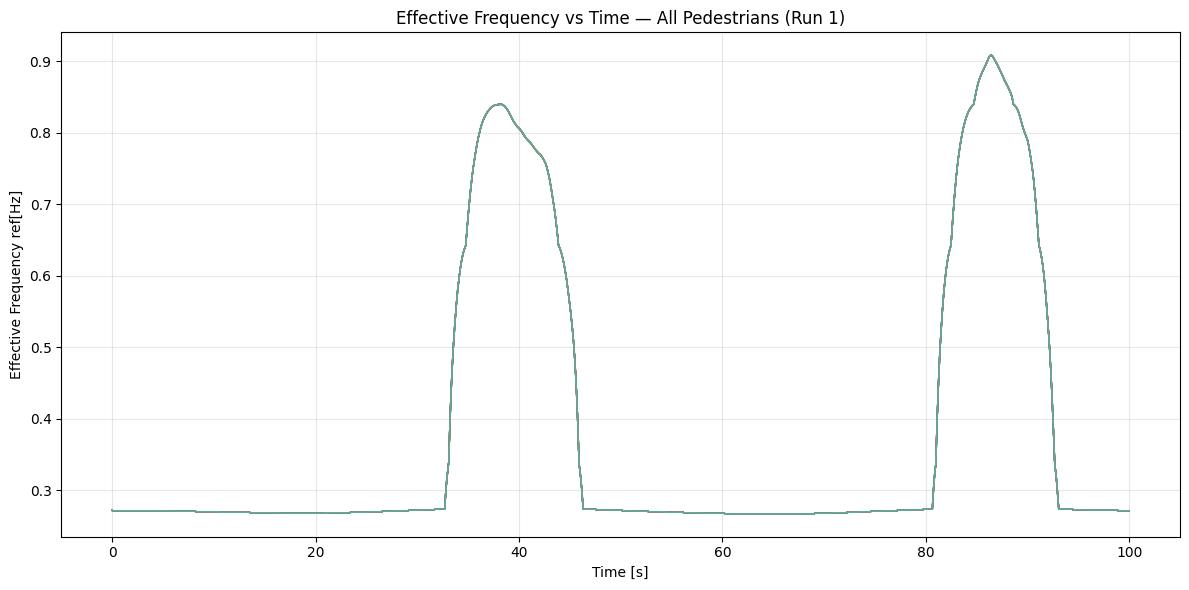

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ---- pick which run to plot (0 if you used NUM_SIMULATIONS=1) ----
run_idx = 0

# Use the time vector returned by the simulation (best)
t_run = np.asarray(t[run_idx])  # t is from: t, eff_damping_series, eff_frequency_series, ... = zip(*results)

# This should be (n_time, numped) e.g., (1000, 40)
F = np.asarray(eff_frequency_series[run_idx])

print("F shape (time, peds) =", F.shape)

plt.figure(figsize=(12, 6))

# plot all pedestrians (each column is one pedestrian DOF)
for j in range(F.shape[1]):
    plt.plot(t_run[:F.shape[0]], F[:, j], lw=1, alpha=0.6)

plt.xlabel("Time [s]")
plt.ylabel("Effective Frequency ref""[Hz]")
plt.title(f"Effective Frequency vs Time — All Pedestrians (Run {run_idx+1})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Z shape (time, peds) = (10000, 20)


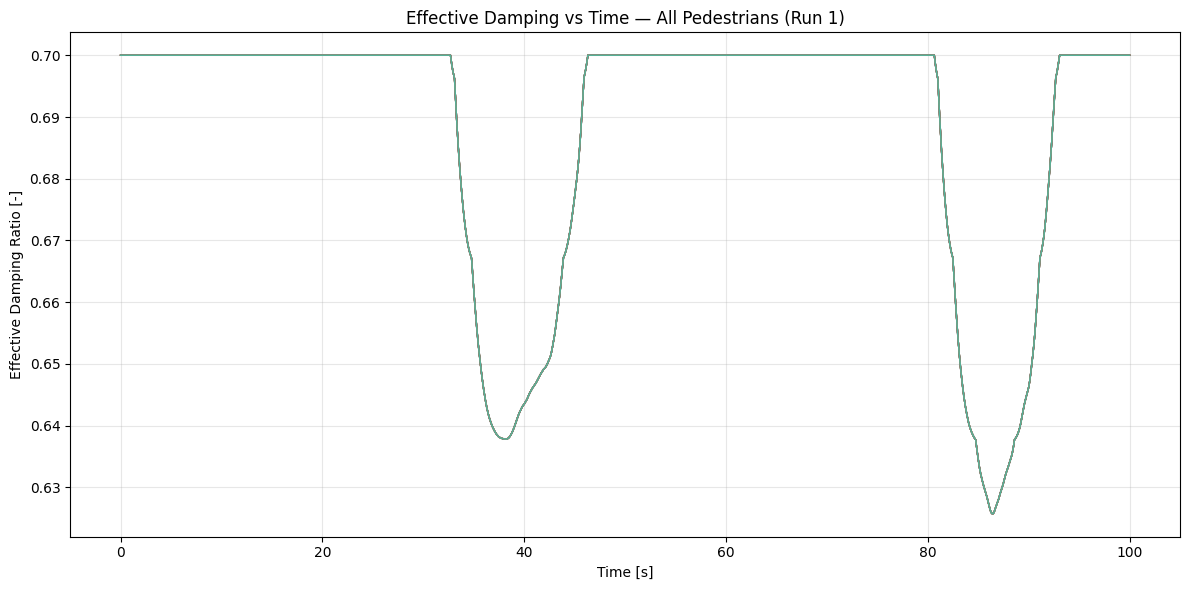

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---- pick which run to plot ----
run_idx = 0   # since NUM_SIMULATIONS = 1

# time vector from simulation (best practice)
t_run = np.asarray(t[run_idx])

# Damping array: shape (time, numped) → (1000, 40)
Z = np.asarray(eff_damping_series[run_idx])

print("Z shape (time, peds) =", Z.shape)

plt.figure(figsize=(12, 6))

# plot all pedestrians
for j in range(Z.shape[1]):
    plt.plot(t_run[:Z.shape[0]], Z[:, j], lw=1, alpha=0.6)

plt.xlabel("Time [s]")
plt.ylabel("Effective Damping Ratio [-]")
plt.title("Effective Damping vs Time — All Pedestrians (Run 1)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


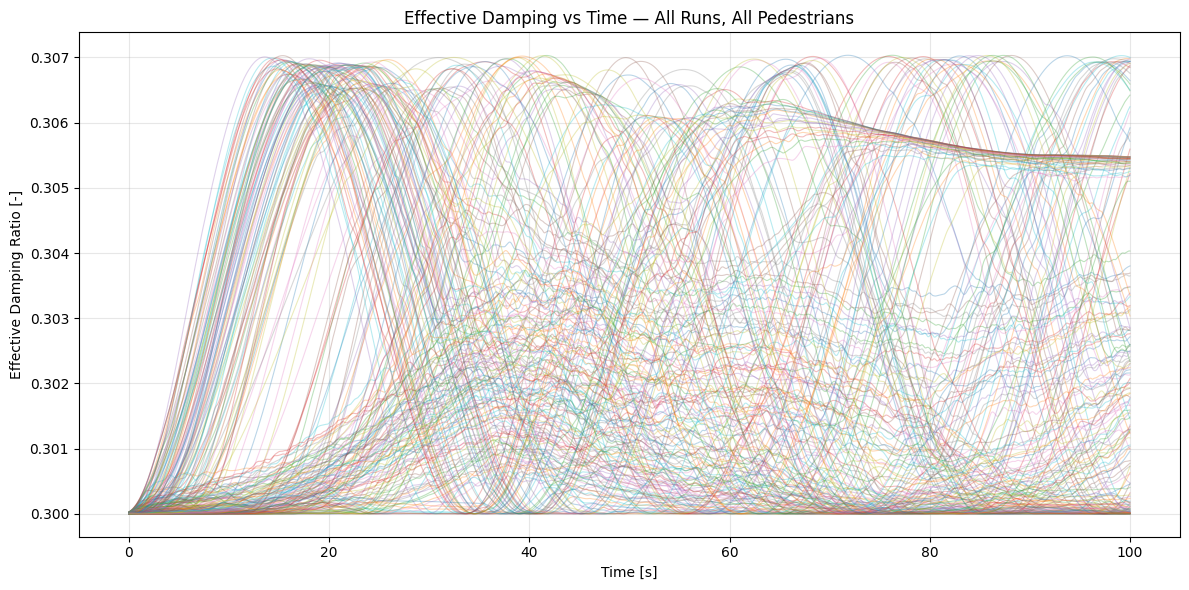

In [27]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for run_idx in range(len(eff_damping_series)):
    t_run = np.asarray(t[run_idx])
    Z = np.asarray(eff_damping_series[run_idx])  # (time, numped)

    for j in range(Z.shape[1]):  # loop over pedestrians
        plt.plot(
            t_run[:Z.shape[0]],
            Z[:, j],
            lw=0.8,
            alpha=0.3
        )

plt.xlabel("Time [s]")
plt.ylabel("Effective Damping Ratio [-]")
plt.title("Effective Damping vs Time — All Runs, All Pedestrians")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for run_idx in range(len(eff_frequency_series)):
    t_run = np.asarray(t[run_idx])
    F = np.asarray(eff_frequency_series[run_idx])  # (time, numped)

    print(f"Run {run_idx+1}, F shape =", F.shape)

    # plot all pedestrians for this run
    for j in range(F.shape[1]):
        plt.plot(
            t_run[:F.shape[0]],
            F[:, j],
            lw=0.8,
            alpha=0.3
        )

plt.xlabel("Time [s]")
plt.ylabel(r"$f_h$ [Hz]")
plt.title("Effective Frequency vs Time — All Runs, All Pedestrians")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Run 1, F shape = (10000,)


IndexError: tuple index out of range

<Figure size 1200x600 with 0 Axes>

Ran 10 simulations.
Time vector length: 10000
f_series length of first run: 10000
zeta_series length of first run: 10000


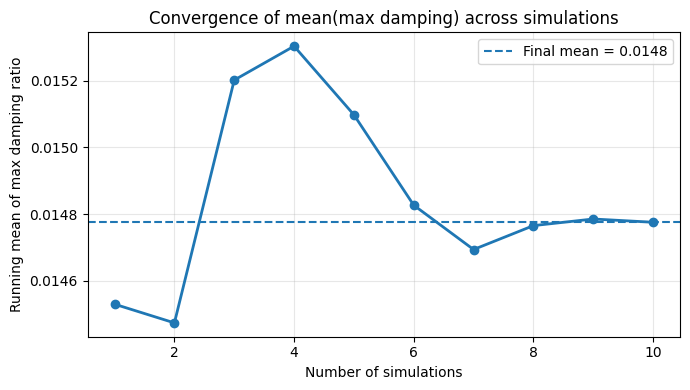

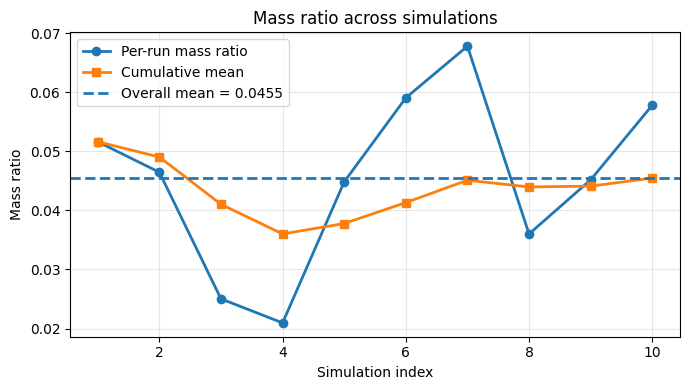

In [5]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import torch
import socialforce
import matplotlib.pyplot as plt
from socialforcefunctions import initial_state_corridor
from solver import Newmarksuper_HSIsocial, compute_1sec_rms_mean
from matrix import bridge
from pedestrian import Pedestrian
from EffectiveFrequencyandDampingofBridge import run_simulation

# Define Monte Carlo settings
NUM_SIMULATIONS = 10 # Number of Monte Carlo runs (increase for better statistics)
NUM_PROCESSES = 10  # Use all available CPU cores
length = 50.0
pedvelocity = 1.25
hht = 0.01
PEDS_DAMPING   = 0.3
PEDS_BODY_F    = 3.1
beam_freq = 2.0

if __name__ == "__main__":
    # safer on Windows/BLAS-heavy code
    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # give each worker a distinct, reproducible seed
    # Simpler approach - generate random seeds directly
    np.random.seed()  # Initialize with system time
    seeds = [np.random.randint(0, 2**31 - 1) for _ in range(NUM_SIMULATIONS)]
    args_list = [(seed, PEDS_DAMPING, PEDS_BODY_F, beam_freq) for seed in seeds]

    with mp.get_context("spawn").Pool(processes=NUM_PROCESSES) as pool:
        results = pool.map(run_simulation, args_list)

    # results is a list of tuples: (t, f_series, zeta_series, lam_series)
    # unpack if you want to aggregate or inspect
    t, eff_damping_series, eff_frequency_series, mass_ratio,numped = zip(*results)

    # Example: use the first run’s timebase and plot mode-1 f(t), ζ(t)
    t0      = t[0]
    f_mode1 = [np.array(f) for f in eff_frequency_series]   # list of arrays
    z_mode1 = [np.array(z) for z in eff_damping_series]

    # Optional: compute across-run means
    f_mean = np.nanmean(np.vstack(f_mode1), axis=0)
    z_mean = np.nanmean(np.vstack(z_mode1), axis=0)

    # Quick check
    print(f"Ran {len(results)} simulations.")
    print(f"Time vector length: {t0.size}")
    print(f"f_series length of first run: {len(eff_frequency_series[0])}")
    print(f"zeta_series length of first run: {len(eff_damping_series[0])}")
    # === Convergence of mean of per-run MAX damping ===
    # One scalar per run: max ζ over time (and modes)
    zeta_max_per_run = np.array([np.nanmax(z) for z in eff_damping_series], dtype=float)

    # Running (cumulative) mean across simulations 1..N
    N = np.arange(1, zeta_max_per_run.size + 1)
    running_mean = np.cumsum(zeta_max_per_run) / N

    # Plot convergence
    plt.figure(figsize=(7,4))
    plt.plot(N, running_mean, marker='o', linewidth=2)
    plt.axhline(running_mean[-1], linestyle='--', label=f'Final mean = {running_mean[-1]:.4f}')
    plt.xlabel('Number of simulations')
    plt.ylabel('Running mean of max damping ratio')
    plt.title('Convergence of mean(max damping) across simulations')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Mass ratio across simulations: per-run, cumulative mean, overall mean ---
mass_ratio_arr = np.asarray(mass_ratio, dtype=float)
runs = np.arange(1, mass_ratio_arr.size + 1)

# Robust cumulative mean that ignores NaNs
valid = np.isfinite(mass_ratio_arr)
cum_sum   = np.cumsum(np.where(valid, mass_ratio_arr, 0.0))
cum_count = np.cumsum(valid.astype(int))
cum_mean  = np.divide(cum_sum, np.maximum(cum_count, 1))

overall_mean = np.nanmean(mass_ratio_arr)

plt.figure(figsize=(7,4))
plt.plot(runs, mass_ratio_arr, marker='o', linewidth=2, label='Per-run mass ratio')
plt.plot(runs, cum_mean, marker='s', linewidth=2, label='Cumulative mean')
plt.axhline(overall_mean, linestyle='--', linewidth=2,
            label=f'Overall mean = {overall_mean:.4f}')
plt.xlabel('Simulation index')
plt.ylabel('Mass ratio')
plt.title('Mass ratio across simulations')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

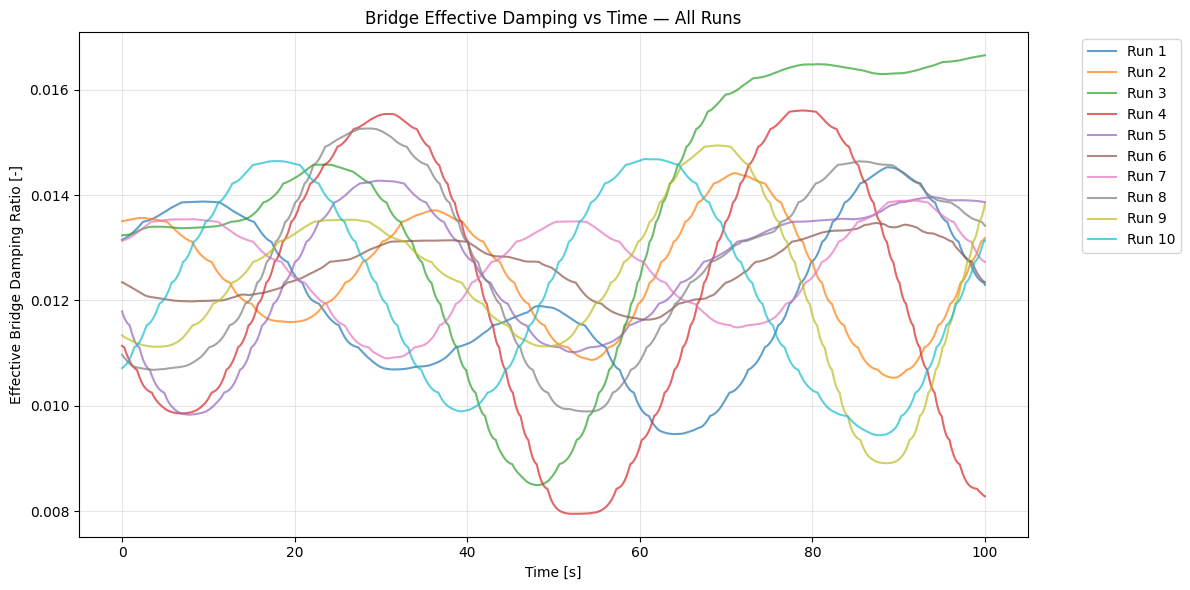

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for run_idx in range(len(eff_damping_series)):
    t_run = np.asarray(t[run_idx])
    Z = np.asarray(eff_damping_series[run_idx])  # (time,)

    plt.plot(
        t_run[:Z.shape[0]],
        Z,
        lw=1.5,
        alpha=0.7,
        label=f"Run {run_idx+1}"
    )

plt.xlabel("Time [s]")
plt.ylabel("Effective Bridge Damping Ratio [-]")
plt.title("Bridge Effective Damping vs Time — All Runs")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Run 1, F shape = (10000,)
Run 2, F shape = (10000,)
Run 3, F shape = (10000,)
Run 4, F shape = (10000,)
Run 5, F shape = (10000,)
Run 6, F shape = (10000,)
Run 7, F shape = (10000,)
Run 8, F shape = (10000,)
Run 9, F shape = (10000,)
Run 10, F shape = (10000,)


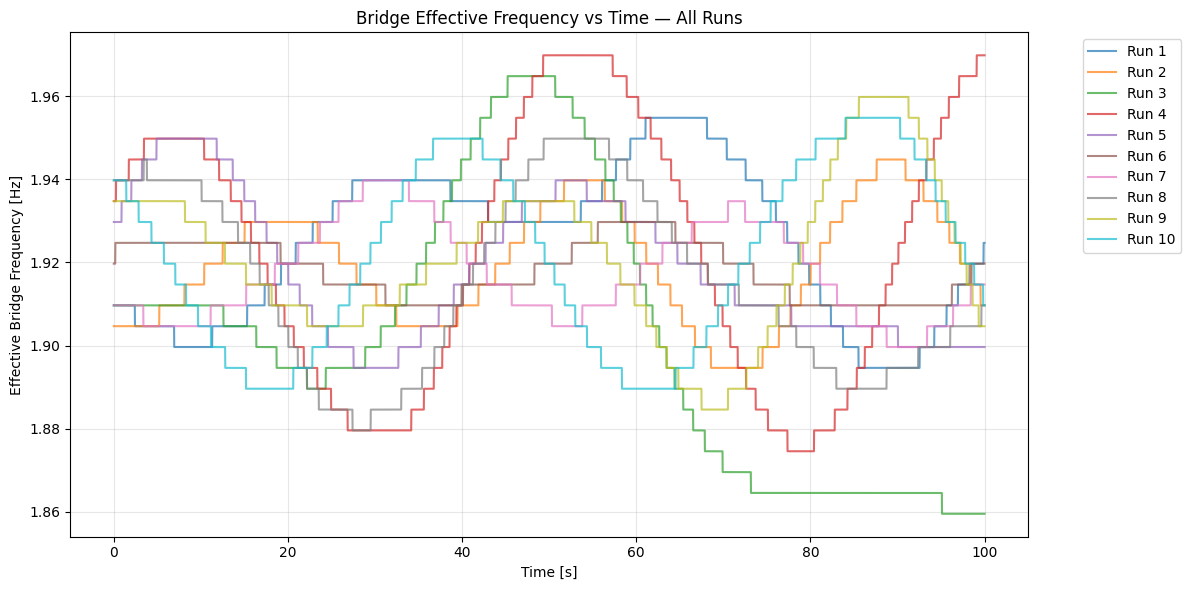

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for run_idx in range(len(eff_frequency_series)):
    t_run = np.asarray(t[run_idx])
    F = np.asarray(eff_frequency_series[run_idx])  # (time,)

    print(f"Run {run_idx+1}, F shape =", F.shape)

    plt.plot(
        t_run[:F.shape[0]],
        F,
        lw=1.5,
        alpha=0.7,
        label=f"Run {run_idx+1}"
    )

plt.xlabel("Time [s]")
plt.ylabel("Effective Bridge Frequency [Hz]")
plt.title("Bridge Effective Frequency vs Time — All Runs")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
